In [36]:
from pathlib import Path
import io, gzip, unicodedata
import os, sys, platform, random
import numpy as np
import regex as re                      #imports fromm libraruy
from xml.etree import ElementTree as ET


import torch
from datasets import Dataset
import evaluate
import inspect
from transformers import (
AutoTokenizer,
AutoModelForSeq2SeqLM,
DataCollatorForSeq2Seq,
TrainingArguments,
Trainer,
)

In [37]:
# --------- Run knobs ---------
SEED = 42
PROJECT_DIR = "./nllb_bilingual_en_es_pt"
ROOT = Path(r"J:\FINAL PROJECT") #path to root directory
TMX_ES = ROOT / "data" / "en-es.tmx"
TMX_PT = ROOT / "data" / "en-pt.tmx"


# dataset sizes
MAX_SAMPLES = 1200 # max per pair (train pool) #samplees to be used for training
EVAL_SAMPLES = 300 # max per pair (eval pool)


# tokenization / model
MAX_SRC_LEN = 64 #maximum source length
MAX_TGT_LEN = 64 #maximum target length


# training
BATCH = 8    # per-GPU batch size
GRAD_ACCUM = 1 # gradient accumulation steps
MAX_STEPS = 100 # max training steps
LR = 3e-5    # learning rate 


# language codes for NLLB
NLLB_CKPT = "facebook/nllb-200-distilled-600M"  # model checkpoint
SRC_LANG = "eng_Latn" # source language code
ES_LANG = "spa_Latn"    # target language code for Spanish
PT_LANG = "por_Latn"  # target language code for Portuguese


# fast-eval presets
FAST_MAX_NEW = 96 # max new tokens
FAST_MIN_NEW = 2
FAST_BEAMS = 1 #beam search
FAST_BATCH = 128

In [38]:
# 1) Repro & device
# ================
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
use_bf16 = torch.cuda.is_available() and getattr(torch.cuda, "is_bf16_supported", lambda: False)()
use_fp16 = torch.cuda.is_available() and not use_bf16
os.makedirs(PROJECT_DIR, exist_ok=True)



In [39]:
# TMX loader with a light cleaner setup for bilingual datasets 

def _nfc_ws(s: str) -> str:   #normalize unicode and whitespace
    s = unicodedata.normalize("NFC", s or "")
    s = s.replace("\u00A0", " ").replace("\u202F", " ")
    return re.sub(r"\s+", " ", s).strip()

def _norm_lang(tag: str) -> str:    #normalize language tags
    if not tag: return ""
    t = tag.replace("_", "-").lower()
    if t.startswith("eng"): return "en"
    if t.startswith("spa"): return "es"
    if t.startswith("por"): return "pt"
    return t.split("-")[0]

def _open_maybe_gz(path: str):
    return io.TextIOWrapper(gzip.open(path, "rb"), encoding="utf-8", errors="ignore") if path.endswith(".gz") \
           else io.open(path, "r", encoding="utf-8", errors="ignore")

def load_tmx_as_dataset(tmx_path: str, src="en", tgt="es", max_samples=None, seed=42) -> Dataset:
    p = Path(tmx_path); assert p.exists(), f"Missing TMX: {tmx_path}"
    src = _norm_lang(src); tgt = _norm_lang(tgt)
    pairs = []
    with _open_maybe_gz(str(p)) as fh:
        context = ET.iterparse(fh, events=("start", "end"))
        _, root = next(context)
        cur_src = cur_tgt = None
        for event, elem in context:
            tag = elem.tag.lower()
            if event == "start" and tag.endswith("tu"):
                cur_src = cur_tgt = None
            if event == "end" and tag.endswith("tuv"):
                lang = _norm_lang(elem.attrib.get("{http://www.w3.org/XML/1998/namespace}lang",
                                                  elem.attrib.get("lang","")))
                seg = next((c for c in elem if c.tag.lower().endswith("seg")), None)
                if seg is not None:
                    text = _nfc_ws("".join(seg.itertext()))
                    if lang == src: cur_src = text
                    elif lang == tgt: cur_tgt = text
            if event == "end" and tag.endswith("tu"):
                if cur_src and cur_tgt:
                    pairs.append((cur_src, cur_tgt))
                root.clear()
                if max_samples and len(pairs) >= max_samples:
                    break

    if max_samples and len(pairs) > max_samples:
        rnd = random.Random(seed)
        idx = list(range(len(pairs))); rnd.shuffle(idx); idx = idx[:max_samples]
        pairs = [pairs[i] for i in idx]

    return Dataset.from_dict({
        "src_text": [s for s,_ in pairs],
        "tgt_text": [t for _,t in pairs]
    })

def light_clean(ds: Dataset, src_lang_check="en"): #light cleaning function
    import langid
    langid.set_languages([src_lang_check])

    URL_RE = re.compile(r"(https?://\S+|www\.\S+)")
    PUNCT_ONLY_RE = re.compile(r"^\p{P}+$", re.UNICODE)

    def clean_example(ex):
        s = URL_RE.sub("<URL>", _nfc_ws(ex["src_text"]))  #replace URLs with <URL>
        t = URL_RE.sub("<URL>", _nfc_ws(ex["tgt_text"])) 
        return {"src_text": s, "tgt_text": t}

    def ok(ex):
        s,t = ex["src_text"], ex["tgt_text"]    #filtering criteria which removes unwanted examples
        if len(s.split()) < 2 or len(t.split()) < 2: return False 
        if PUNCT_ONLY_RE.match(s) or PUNCT_ONLY_RE.match(t): return False #remove punctuation-only sentences
        if len(s.split()) > 200 or len(t.split()) > 200: return False #remove overly long sentences
        ls, cs = langid.classify(s) #language identification
        if ls != src_lang_check and cs > 0.7: return False
        return True

    def dedup(ds_): #deduplication function which removes duplicate entries
        seen, keep = set(), []
        for i, ex in enumerate(ds_):
            k = (ex["src_text"].lower(), ex["tgt_text"].lower())
            if k not in seen:
                seen.add(k); keep.append(i)
        return ds_.select(keep)

    ds = ds.map(clean_example)
    ds = dedup(ds)
    ds = ds.filter(ok)
    return ds

# Load raw + clean
ds_es_all = light_clean(load_tmx_as_dataset(TMX_ES, "en", "es", MAX_SAMPLES+EVAL_SAMPLES, SEED))
ds_pt_all = light_clean(load_tmx_as_dataset(TMX_PT, "en", "pt", MAX_SAMPLES+EVAL_SAMPLES, SEED))




Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1500 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1499 [00:00<?, ? examples/s]

In [40]:

es_eval = min(EVAL_SAMPLES, max(50, int(0.10 * len(ds_es_aligned))))
pt_eval = min(EVAL_SAMPLES, max(50, int(0.10 * len(ds_pt_aligned))))

split_es = ds_es_aligned.train_test_split(test_size=es_eval, seed=SEED, shuffle=True)
split_pt = ds_pt_aligned.train_test_split(test_size=pt_eval, seed=SEED, shuffle=True)

train_es, valid_es = split_es["train"], split_es["test"]
train_pt, valid_pt = split_pt["train"], split_pt["test"]

print("Final split sizes (BLEUALIGN):",
      f"EN→ES train {len(train_es)} / valid {len(valid_es)}  |  EN→PT train {len(train_pt)} / valid {len(valid_pt)}")


Final split sizes (BLEUALIGN): EN→ES train 1349 / valid 149  |  EN→PT train 1343 / valid 149


In [41]:
print("Final split sizes:",
      f"EN→ES train {len(train_es)} / valid {len(valid_es)}  |  EN→PT train {len(train_pt)} / valid {len(valid_pt)}")

Final split sizes: EN→ES train 1349 / valid 149  |  EN→PT train 1343 / valid 149


In [42]:
import random, re, pandas as pd
import matplotlib.pyplot as plt

def show_random_pairs(ds, n=10, seed=42):
    rng = random.Random(seed)
    idxs = rng.sample(range(len(ds)), min(n, len(ds)))
    for i in idxs:
        print(f"\n=== SAMPLE {i} ===")
        print("SRC:", ds[i]["src_text"])
        print("TGT:", ds[i]["tgt_text"])

def show_table(ds, start=0, count=15):
    end = min(start + count, len(ds))
    df = pd.DataFrame({
        "EN (src)": [ds[i]["src_text"] for i in range(start, end)],
        "XX (tgt)": [ds[i]["tgt_text"] for i in range(start, end)],
        "idx": list(range(start, end)),
    })
    df = df[["idx","EN (src)","XX (tgt)"]]
    display(df)

def inspect(ds, start=0, count=20):
    for i in range(start, min(start + count, len(ds))):
        print(f"\n[{i}]")
        print("EN:", ds[i]["src_text"])
        print("XX:", ds[i]["tgt_text"])

_num_re = re.compile(r"\d+(?:[.,]\d+)?%?")

def highlight_numbers(ds, idx):
    s, t = ds[idx]["src_text"], ds[idx]["tgt_text"]
    print(f"\n[{idx}]")
    print("EN:", s)
    print("XX:", t)
    print("EN nums:", _num_re.findall(s), " | XX nums:", _num_re.findall(t))

def plot_length_ratios(ds, title="Length ratios (src/tgt)"):
    ratios = []
    for ex in ds:
        s = len(ex["src_text"].split())
        t = len(ex["tgt_text"].split())
        if t > 0:
            ratios.append(s/t)
    plt.figure()
    plt.hist(ratios, bins=50)
    plt.title(title)
    plt.xlabel("src_words / tgt_words")
    plt.ylabel("count")
    plt.show()
    return ratios

def show_worst_by_ratio(ds, top=20):  #show examples with worst length ratios
    ratios = []
    for i, ex in enumerate(ds):
        s = len(ex["src_text"].split())
        t = len(ex["tgt_text"].split())
        if t > 0:
            ratios.append((i, abs((s/t) - 1.0)))
    ratios.sort(key=lambda x: x[1], reverse=True)
    for i, _ in ratios[:top]:
        inspect(ds, start=i, count=1)


In [34]:
#  Produce aligned datasets with BleuAlign (or fallback)

# Make sure the bleualign functions are loaded (from the earlier cell).

try:
    bleualign_align
except NameError as e:
    raise RuntimeError("BleuAlign functions not defined. Run the 'CELL 1.5: BleuAlign-like alignment' cell first.") from e

# ds_es_all and ds_pt_all come from your TMX loader/cleaner in CELL 1
try:
    print("Running BleuAlign for EN→ES…")
    ds_es_aligned = bleualign_align(ds_es_all, mod_es, tok_es, "en-es", ES_LANG)
    print("Running BleuAlign for EN→PT…")
    ds_pt_aligned = bleualign_align(ds_pt_all, mod_pt, tok_pt, "en-pt", PT_LANG)
except Exception as ex:
    # Fallback so your notebook still runs even if alignment has an issue
    print("⚠️ BleuAlign failed or was skipped. Falling back to raw cleaned datasets.")
    print("Reason:", repr(ex))
    ds_es_aligned = ds_es_all
    ds_pt_aligned = ds_pt_all

print("Aligned sizes:",
      f"EN→ES {len(ds_es_aligned)} | EN→PT {len(ds_pt_aligned)}")


Running BleuAlign for EN→ES…
[en-es] MT 1498 src sentences to spa_Latn…


KeyboardInterrupt: 

🔎 EN→ES random pairs:

=== SAMPLE 1309 ===
SRC: 92ss. It is clear that a legal price below 10USD by squared meter has no relation with real prices Jenkis 2001, p.
TGT: Un precio legal por debajo de 10 dólares por metro cuadrado no tiene mucha relación con valores reales. Véase Jenkis 2001, pág. 249. Resolución Nº 35/2010 del Ministerio Trabajo y Seguridad social, en GO Esp.

=== SAMPLE 228 ===
SRC: Hemochromatosis type 4 is caused by the mutation of the ferroportin gene 4. There are other hereditary types associated with iron overload.
TGT: En este espectro de tipos y posibles mutaciones hay un modo de transmisión autosómico recesivo con la excepción de la hemocromatosis tipo 4 la cual tiene un modo de transmisión dominante 4.

=== SAMPLE 51 ===
SRC: Philosophical activity corresponds to its time.
TGT: La actividad filosófica tiene correspondencias con su tiempo.

=== SAMPLE 563 ===
SRC: Philosophical activity has had a consistently self-critical history; this has been a way of alertin

,idx,EN (src),XX (tgt)
0,0,Are there alternatives to our educational models?,¿Existen alternativas para buscar otros modelo...
1,1,The facts mentioned in history texts written b...,Los hechos mencionados en los textos histórico...
2,2,Results: Description of examples of non-invasi...,Historia del artículo: Recibido el 8 de julio ...
3,3,The study objectives were explained to the mot...,Se explicó a las madres los objetivos del estu...
4,4,What is bioethics about?,¿De qué trata la bioética?
5,5,Mutation C282Y has a substitution of amino aci...,En la mutación C282Y hay una sustitución de am...
6,6,It was a clear incentive for officials to real...,"Esta transformación, como ya se ha analizado, ..."
7,7,"Corresponding author at: Calle 42, 22-29, Bogo...","Autor para correspondencia: Calle 42 22-29, Bo..."
8,8,This does not imply disorganized learning; on ...,Esto no significa que sea un aprendizaje desor...
9,9,Authorized artisans have to pay taxes and duti...,Los titulares de licencias deben pagar impuest...



📈 EN→ES length ratios (train):


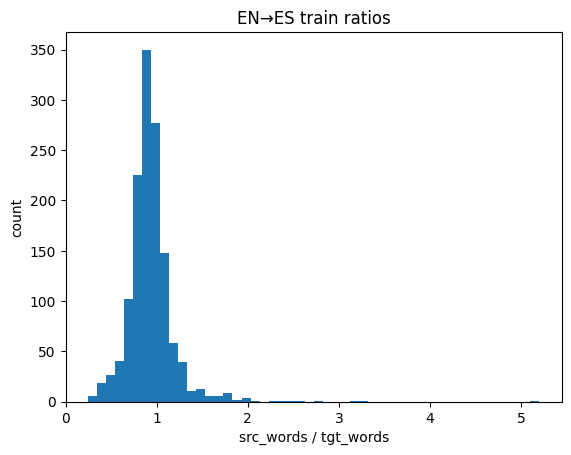


🚩 EN→ES worst by ratio (top 10):

[428]
EN: Pedro Serrano RodrÃ guez in his article Post-earthquake Geodesics.Applied Research on Emergencies presents a study carried out by the Universidad TÃ©cnica Federico Santa MarÃ a, Chile.
XX: El artículo "Geodésicos post terremoto.

[313]
EN: The jury decided that the winning proposal came from a housewife with a child who suffered from a chronic illness and was under expensive treatment for life, for which she was required to go to the Mexican Institute of Social Security the Mexican government's social security institute each month to receive the medication and go through 17 clearance procedures to get it.
XX: Así, los funcionarios de gobierno, al ejercer en el sector público debiéramos atenernos solamente a lo escrito y señalado.

[324]
EN: It predicts recovery from neuromuscular blockade balance between anticholinesterase activity and spontaneous recovery from neuromuscular blockade.
XX: Nuevos conocimientos, curva de aprendizaje.

[198]
EN

In [43]:
print("🔎 EN→ES random pairs:")
show_random_pairs(train_es, n=8)

print("\n📋 EN→ES table view (first 15):")
show_table(train_es, start=0, count=15)

print("\n📈 EN→ES length ratios (train):")
_ = plot_length_ratios(train_es, title="EN→ES train ratios")

print("\n🚩 EN→ES worst by ratio (top 10):")
show_worst_by_ratio(train_es, top=10)

# (optional) check numbers on any suspicious index
# highlight_numbers(train_es, idx=123)


In [ ]:
print("🔎 EN→PT random pairs:")
show_random_pairs(train_pt, n=8)

print("\n📋 EN→PT table view (first 15):")
show_table(train_pt, start=0, count=15)

print("\n📈 EN→PT length ratios (train):")
_ = plot_length_ratios(train_pt, title="EN→PT train ratios")

print("\n🚩 EN→PT worst by ratio (top 10):")
show_worst_by_ratio(train_pt, top=10)

# (optional) check numbers on any suspicious index
# highlight_numbers(train_pt, idx=77)


In [55]:
def clean_ratio(ds, lo=0.6, hi=1.6, min_words=5): #cleaning function based on length ratios
    keep = []
    for i, ex in enumerate(ds):
        s = len(ex["src_text"].split())
        t = len(ex["tgt_text"].split())
        if t == 0:
            continue
        r = s / t
        if lo <= r <= hi and s >= min_words and t >= min_words:
            keep.append(i)
    return ds.select(keep)

print("Before cleaning:", len(train_es), len(valid_es))
train_es = clean_ratio(train_es)
valid_es = clean_ratio(valid_es)
print("After cleaning:", len(train_es), len(valid_es))


Before cleaning: 1236 135
After cleaning: 1236 135


In [57]:
def clean_ratio(ds, lo=0.6, hi=1.6, min_words=5): #cleaning function based on length ratios
    keep = []
    for i, ex in enumerate(ds):
        s = len(ex["src_text"].split())
        t = len(ex["tgt_text"].split())
        if t == 0:
            continue
        r = s / t
        if lo <= r <= hi and s >= min_words and t >= min_words:
            keep.append(i)
    return ds.select(keep)

print("Before cleaning:", len(train_pt), len(valid_pt))
train_pt = clean_ratio(train_pt)
valid_pt = clean_ratio(valid_pt)
print("After cleaning:", len(train_pt), len(valid_pt))


Before cleaning: 1288 141
After cleaning: 1288 141


In [58]:
# ==== CELL 3: Tokenizers, models, forced BOS setup ====

def forced_bos_id(tok, lang_code: str) -> int:
    m = getattr(tok, "lang_code_to_id", None)
    if isinstance(m, dict) and lang_code in m:
        return m[lang_code]
    if hasattr(tok, "get_lang_id"):
        return tok.get_lang_id(lang_code)
    i = tok.convert_tokens_to_ids(lang_code)
    if i is None or i == tok.unk_token_id:
        raise RuntimeError(f"Cannot resolve BOS id for {lang_code}")
    return i

def build_nllb_pair(lang_code: str):
    tok = AutoTokenizer.from_pretrained(NLLB_CKPT, use_fast=True)
    tok.src_lang = SRC_LANG
    tok.tgt_lang = lang_code

    model = AutoModelForSeq2SeqLM.from_pretrained(NLLB_CKPT)
    lang_id = forced_bos_id(tok, lang_code)

    for cfg in (model.config, model.generation_config):
        cfg.forced_bos_token_id = lang_id
        cfg.decoder_start_token_id = lang_id

    if device == "cuda":
        model.to(device)
    return tok, model

tok_es, mod_es = build_nllb_pair(ES_LANG)
tok_pt, mod_pt = build_nllb_pair(PT_LANG)


In [17]:
# ==== CELL 2: Split train/valid (aligned) ====
es_eval = min(EVAL_SAMPLES, max(50, int(0.10 * len(ds_es_aligned))))
pt_eval = min(EVAL_SAMPLES, max(50, int(0.10 * len(ds_pt_aligned))))

split_es = ds_es_aligned.train_test_split(test_size=es_eval, seed=SEED, shuffle=True)
split_pt = ds_pt_aligned.train_test_split(test_size=pt_eval, seed=SEED, shuffle=True)

train_es, valid_es = split_es["train"], split_es["test"]
train_pt, valid_pt = split_pt["train"], split_pt["test"]

print("Final split sizes (BLEUALIGN):",
      f"EN→ES train {len(train_es)} / valid {len(valid_es)}  |  EN→PT train {len(train_pt)} / valid {len(valid_pt)}")


Final split sizes (BLEUALIGN): EN→ES train 1349 / valid 149  |  EN→PT train 1343 / valid 149


In [ ]:

 # peprocessing ====

def preprocess(ds, tok):
    def _fn(batch):
        X = tok(batch["src_text"], truncation=True, max_length=MAX_SRC_LEN)
        try:
            Y = tok(text_target=batch["tgt_text"], truncation=True, max_length=MAX_TGT_LEN)
        except TypeError:
            from contextlib import contextmanager
            cm = tok.as_target_tokenizer() if hasattr(tok, "as_target_tokenizer") else contextmanager(lambda: (yield))()
            with cm:
                Y = tok(batch["tgt_text"], truncation=True, max_length=MAX_TGT_LEN)
        X["labels"] = Y["input_ids"]
        return X
    return ds.map(_fn, batched=True, remove_columns=ds.column_names)

train_es_tok = preprocess(train_es, tok_es)
valid_es_tok = preprocess(valid_es, tok_es)
train_pt_tok = preprocess(train_pt, tok_pt)
valid_pt_tok = preprocess(valid_pt, tok_pt)


In [19]:
# ==== CELL 5: Fast zero-shot eval ====

bleu_metric = evaluate.load("sacrebleu")
chrf_metric = evaluate.load("chrf")

def _autocast_if_cuda():
    if torch.cuda.is_available():
        return torch.autocast("cuda", dtype=torch.bfloat16 if use_bf16 else torch.float16)
    return torch.cuda.amp.autocast(enabled=False)

@torch.inference_mode()
def batch_generate_fast(model, tok, texts,
                        max_len_src=MAX_SRC_LEN, max_new=FAST_MAX_NEW,
                        beams=FAST_BEAMS, batch_size=FAST_BATCH,
                        pad_to_multiple_of=8):

    enc = tok(texts, return_tensors="pt", padding=True, truncation=True,
              max_length=max_len_src, pad_to_multiple_of=pad_to_multiple_of)
    enc = {k: v.to(model.device) for k, v in enc.items()}
    lang_id = forced_bos_id(tok, tok.tgt_lang)

    preds = []
    model.eval()
    if getattr(model.config, "use_cache", True) is False:
        model.config.use_cache = True

    with _autocast_if_cuda():
        for i in range(0, enc["input_ids"].size(0), batch_size):
            sl = slice(i, i+batch_size)
            out = model.generate(
                input_ids=enc["input_ids"][sl],
                attention_mask=enc.get("attention_mask", None)[sl] if enc.get("attention_mask") is not None else None,
                max_new_tokens=max_new,
                min_new_tokens=FAST_MIN_NEW,
                num_beams=beams,
                no_repeat_ngram_size=3,
                length_penalty=1.0,
                do_sample=False,
                forced_bos_token_id=lang_id,
                decoder_start_token_id=lang_id,
                use_cache=True,
            )
            preds.extend(tok.batch_decode(out, skip_special_tokens=True))

    return [p.strip() for p in preds]

def evaluate_pair_fast(model, tok, valid_ds, name, limit=128):
    src = [r["src_text"] for r in valid_ds][:limit]
    refs = [r["tgt_text"] for r in valid_ds][:limit]
    preds = batch_generate_fast(model, tok, src)
    refs_bleu = [[r] for r in refs]

    bleu = bleu_metric.compute(predictions=preds, references=refs_bleu)["score"]
    chrf = chrf_metric.compute(predictions=preds, references=refs_bleu)["score"]
    exact = float(np.mean([int(p == r) for p, r in zip(preds, refs)]) * 100.0)

    print(f"{name}: BLEU {bleu:.2f} | chrF {chrf:.2f} | exact {exact:.2f}% on {len(preds)}")
    return {"bleu": bleu, "chrf": chrf, "exact": exact}

print("🔎 EN→ES zero-shot:")
evaluate_pair_fast(mod_es, tok_es, valid_es, "EN→ES zero-shot")

print("🔎 EN→PT zero-shot:")
evaluate_pair_fast(mod_pt, tok_pt, valid_pt, "EN→PT zero-shot")


🔎 EN→ES zero-shot:
EN→ES zero-shot: BLEU 0.12 | chrF 5.03 | exact 0.00% on 128
🔎 EN→PT zero-shot:
EN→PT zero-shot: BLEU 0.00 | chrF 1.34 | exact 0.00% on 128


{'bleu': 0.0013571898169316176, 'chrf': 1.3429845576715884, 'exact': 0.0}

In [ ]:
# ==== CELL 6 (compat): Training that works on older transformers ====
import inspect
from transformers import DataCollatorForSeq2Seq, TrainingArguments, Trainer

def make_training_args(**wanted):
    accepted = set(inspect.signature(TrainingArguments.__init__).parameters.keys())
    filtered = {k: v for k, v in wanted.items() if k in accepted}
    dropped = sorted(set(wanted) - set(filtered))
    if dropped:
        print("Dropped unsupported keys:", dropped)
    return TrainingArguments(**filtered)

def train_one(model, tok, train_tok, out_dir):
    args = make_training_args(
        output_dir=out_dir,
        per_device_train_batch_size=BATCH,
        gradient_accumulation_steps=GRAD_ACCUM,
        max_steps=MAX_STEPS,
        learning_rate=LR,
        # the next ones will be auto-dropped if your version doesn't support them
        lr_scheduler_type="linear",
        warmup_ratio=0.05,
        weight_decay=0.01,
        logging_steps=100,
        report_to="none",
        bf16=use_bf16,
        fp16=use_fp16,
        no_cuda=(device!="cuda"),
        dataloader_num_workers=0,
        dataloader_pin_memory=(device=="cuda"),
        evaluation_strategy="no",
        save_strategy="no",
        optim=("adamw_torch_fused" if device=="cuda" else "adamw_torch"),
        group_by_length=True,
    )

    collator = DataCollatorForSeq2Seq(tokenizer=tok, model=model, padding="longest")
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_tok,
        eval_dataset=None,
        data_collator=collator,
        tokenizer=tok,
    )
    trainer.train()

print("🚀 Training EN→ES …")
train_one(mod_es, tok_es, train_es_tok, out_dir=f"{PROJECT_DIR}/ckpt_es")

print("🚀 Training EN→PT …")
train_one(mod_pt, tok_pt, train_pt_tok, out_dir=f"{PROJECT_DIR}/ckpt_pt")


In [26]:
# ==== CELL 7: Post-train eval + smoke tests ====

print("✅ EN→ES finetuned:")
evaluate_pair_fast(mod_es, tok_es, valid_es, "EN→ES finetuned")

print("✅ EN→PT finetuned:")
evaluate_pair_fast(mod_pt, tok_pt, valid_pt, "EN→PT finetuned")

@torch.inference_mode()
def translate(model, tok, text, max_new_tokens=128, num_beams=4, tgt_lang=None):
    enc = tok([text], return_tensors="pt", padding=True, truncation=True, max_length=MAX_SRC_LEN)
    enc = {k: v.to(model.device) for k, v in enc.items()}
    lang = tgt_lang or tok.tgt_lang
    lang_id = forced_bos_id(tok, lang)
    out = model.generate(
        **enc,
        num_beams=num_beams,
        max_new_tokens=max_new_tokens,
        no_repeat_ngram_size=3,
        early_stopping=True,
        forced_bos_token_id=lang_id,
        decoder_start_token_id=lang_id
    )
    return tok.batch_decode(out, skip_special_tokens=True)[0]

print("ES:", translate(mod_es, tok_es, "This is a small test of a machine translation system."))
print("PT:", translate(mod_pt, tok_pt, "How are you today?"))


✅ EN→ES finetuned:
EN→ES finetuned: BLEU 0.12 | chrF 5.03 | exact 0.00% on 128
✅ EN→PT finetuned:
EN→PT finetuned: BLEU 0.00 | chrF 1.34 | exact 0.00% on 128
ES: en en en.
PT: 


In [ ]:
import random

def show_random_pairs(ds, n=10):
    for i in random.sample(range(len(ds)), n):
        print(f"\n=== SAMPLE {i} ===")
        print("SRC:", ds[i]["src_text"])
        print("TGT:", ds[i]["tgt_text"])
